# 07. Сценарный анализ цены (движок дашборда)

Опорная популяция — **активные лоты последнего labelable среза** (single-month cross-section,
та же популяция, что при обучении → калибровка валидна; не last-snapshot-окно). Это ровно то,
что будет скорить дашборд для «текущего месяца».

Метрики (методология дашборда):
- ожидаемое число продаж `Σ pᵢ` (линейность матожидания);
- **спрос в м² `Q = Σ pᵢ·areaᵢ`** (основной);
- **выручка `R = Σ pᵢ·areaᵢ·priceᵢ·(1+Δ)`**;
- сегментная эластичность `E = ΔQ/(Q·Δ)`.

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "data").is_dir() else _cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import MODEL_DATASET_PARQUET, CALIBRATED_MODEL_PATH, PROCESSED_DIR, TARGET_COL, PRICE_COL
from src.modeling import CalibratedModel  # noqa: F401

C1, C2, C3 = "#2C7BB6", "#D7542B", "#2D9E5F"
plt.rcParams.update({"figure.dpi": 130, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.right": False, "axes.spines.top": False})
FIG_DIR = REPO_ROOT / "reports" / "figures" / "07_scenarios"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PCTS = (-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15)
LBL = [f"{p:+.0%}" for p in PCTS]
HORIZON_CUT = pd.Timestamp("2025-04-30")
MIN_SEG_N, MIN_PROJ_N = 50, 150

## 1. Опорный срез и проверка калибровки

In [2]:
model: CalibratedModel = joblib.load(CALIBRATED_MODEL_PATH)
FEATURES = model.features

df = pd.read_parquet(MODEL_DATASET_PARQUET)
labelable = df[(df["is_sold_past"] == 0) & (df["file_date"] <= HORIZON_CUT)]
REF = labelable["file_date"].max()                       # последний labelable срез
cur = labelable[labelable["file_date"] == REF].copy()

def predict_p(model, X):
    return model.predict_proba(X[FEATURES])[:, 1]

cur["p_base"] = predict_p(model, cur[FEATURES])
exp_sales, act_sales = cur["p_base"].sum(), cur[TARGET_COL].sum()
print(f"опорный срез: {REF.date()}  |  активных лотов: {len(cur):,}  |  supply: {cur['area'].sum():,.0f} м²")
print(f"калибровка: Σp={exp_sales:,.0f} ожид. продаж  vs  факт={act_sales:,.0f}  "
      f"(переоценка ×{exp_sales/act_sales:.2f})")
print(f"база: q_sqm Σp·area = {(cur['p_base']*cur['area']).sum():,.0f} м²  |  "
      f"revenue = {(cur['p_base']*cur['area']*cur['price']).sum()/1e9:.2f} млрд ₽")

опорный срез: 2025-04-02  |  активных лотов: 105,400  |  supply: 5,151,961 м²
калибровка: Σp=2,259 ожид. продаж  vs  факт=1,655  (переоценка ×1.37)
база: q_sqm Σp·area = 96,521 м²  |  revenue = 27.04 млрд ₽


## 2. Сценарный движок (рынок в целом)

In [3]:
# шок уровня цены (src.elasticity): двигаются price, log_price, discount_abs, rel_price;
# price_change_*, rel_price_district, price_gap_to_p10 заморожены. price_rank_seg тоже
# заморожен (seg_cols не передаём).
from src.elasticity import apply_price_shock

def market_curve(data, pcts=PCTS):
    X, area, price = data[FEATURES], data["area"].to_numpy(), data[PRICE_COL].to_numpy()
    rows = []
    for pct in pcts:
        p = predict_p(model, apply_price_shock(X, pct) if pct else X)
        rows.append(dict(pct=pct, mean_p=p.mean(), exp_sales=p.sum(),
                         q_sqm=(p*area).sum(), revenue=(p*area*price*(1+pct)).sum()))
    m = pd.DataFrame(rows)
    q0 = m.loc[m["pct"] == 0, "q_sqm"].iloc[0]
    r0 = m.loc[m["pct"] == 0, "revenue"].iloc[0]
    m["q_chg_%"] = 100*(m["q_sqm"]/q0 - 1)
    m["rev_chg_%"] = 100*(m["revenue"]/r0 - 1)
    return m

market = market_curve(cur)
display(market.assign(pct=LBL).round({"mean_p":4,"exp_sales":0,"q_sqm":0,"q_chg_%":1,"rev_chg_%":1}))

,pct,mean_p,exp_sales,q_sqm,revenue,q_chg_%,rev_chg_%
0,-15%,0.0237,2494.0,106458.0,2.535824e+10,10.3,-6.2
1,-10%,0.0230,2428.0,103787.0,2.614697e+10,7.5,-3.3
2,-5%,0.0223,2346.0,100306.0,2.666196e+10,3.9,-1.4
3,+0%,0.0214,2259.0,96521.0,2.703724e+10,0.0,0.0
4,+5%,0.0208,2189.0,93468.0,2.754211e+10,-3.2,1.9
5,+10%,0.0202,2134.0,91073.0,2.819246e+10,-5.6,4.3
6,+15%,0.0198,2092.0,89252.0,2.898176e+10,-7.5,7.2


## 3. Кривая спроса (м²), выручка и revenue-оптимум (с health-gate)

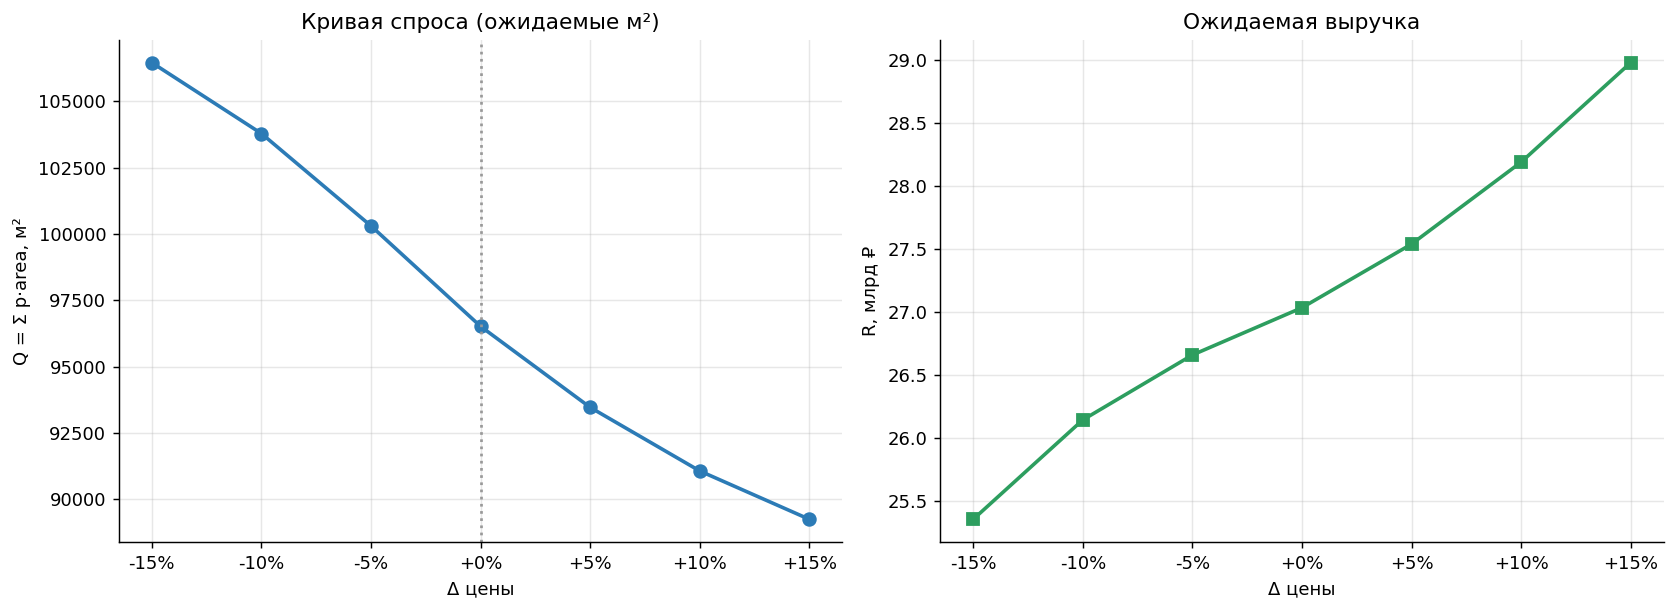

эластичность рынка (area-взвеш., ±5%): -0.708

спрос убывает по цене: True | argmax revenue: Δ=+15%
⚠️ GATE: выручка растёт до края диапазона (+15%) — спрос неэластичен, интерьерного оптимума НЕТ. Модель НЕ ограничивает цену сверху → НЕ выдавать 'поднять цену' как рекомендацию (артефакт неэластичности).


In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
axL.plot(LBL, market["q_sqm"], "o-", color=C1, lw=2, ms=7)
axL.axvline(LBL.index("+0%"), color="0.6", ls=":")
axL.set_title("Кривая спроса (ожидаемые м²)"); axL.set_xlabel("Δ цены"); axL.set_ylabel("Q = Σ p·area, м²")

axR.plot(LBL, market["revenue"]/1e9, "s-", color=C3, lw=2, ms=7)
axR.set_title("Ожидаемая выручка"); axR.set_xlabel("Δ цены"); axR.set_ylabel("R, млрд ₽")
plt.tight_layout(); fig.savefig(FIG_DIR / "fig01_demand_revenue_curves.png", bbox_inches="tight"); plt.show()

# сегментная эластичность рынка (центральная разность ±5%)
q_m5 = market.loc[market["pct"] == -0.05, "q_sqm"].iloc[0]
q_p5 = market.loc[market["pct"] ==  0.05, "q_sqm"].iloc[0]
q_0  = market.loc[market["pct"] ==  0.0,  "q_sqm"].iloc[0]
elast_market = (q_p5 - q_m5) / (q_0 * 0.10)
print(f"эластичность рынка (area-взвеш., ±5%): {elast_market:.3f}")

# HEALTH-GATE на revenue-оптимум
demand_down = bool(np.all(np.diff(market["q_sqm"]) < 0))
i_opt = int(market["revenue"].values.argmax())
interior = 0 < i_opt < len(PCTS) - 1
print(f"\nспрос убывает по цене: {demand_down} | argmax revenue: Δ={PCTS[i_opt]:+.0%}")
if demand_down and interior:
    print(f"✓ revenue-оптимум интерьерный: рекомендуемое Δ={PCTS[i_opt]:+.0%} "
          f"(выручка {market['revenue'].iloc[i_opt]/1e9:.2f} млрд ₽)")
else:
    print(f"⚠️ GATE: выручка растёт до края диапазона ({PCTS[i_opt]:+.0%}) — спрос неэластичен, "
          "интерьерного оптимума НЕТ. Модель НЕ ограничивает цену сверху → "
          "НЕ выдавать 'поднять цену' как рекомендацию (артефакт неэластичности).")

## 4. Сегменты: спрос в м² по регион × класс

pct,region,project_class,-0.1,0.0,0.1,elast_±5%,swing_%
2,Московская область,бизнес,221.0,188.0,169.0,-1.590,27.2
1,Москва,комфорт,18439.0,16946.0,16014.0,-0.803,14.3
4,Новая Москва,комфорт,12540.0,11588.0,10804.0,-0.786,15.0
3,Московская область,комфорт,59677.0,55654.0,52513.0,-0.684,12.9
0,Москва,бизнес,12904.0,12142.0,11570.0,-0.600,11.0


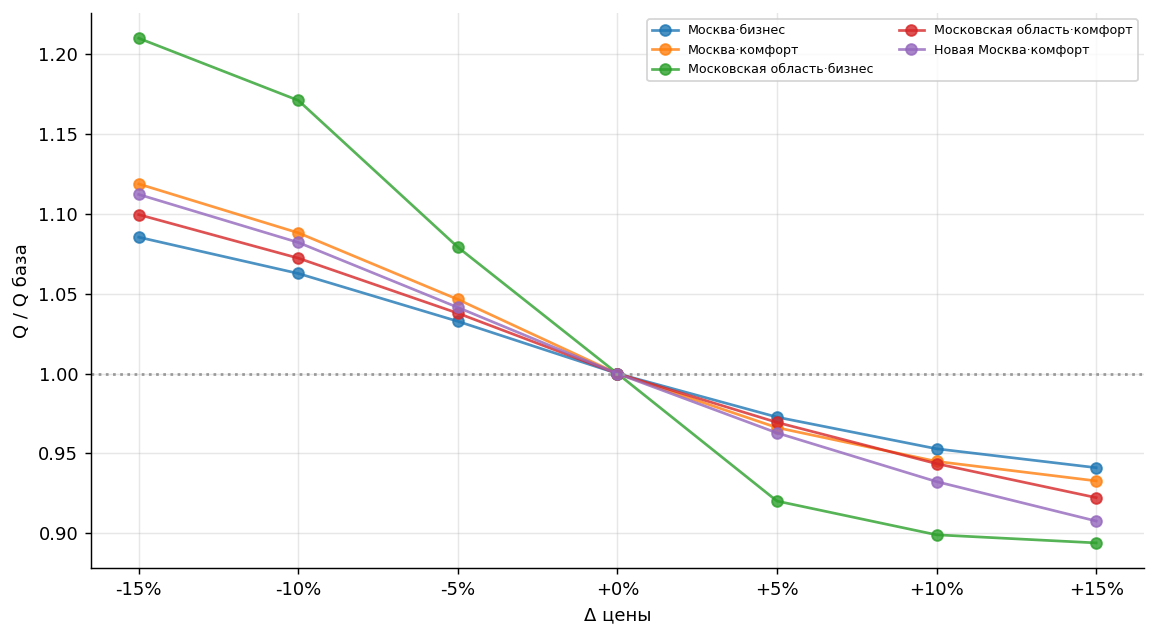

In [5]:
def segment_curves(data, group_cols, pcts=PCTS, min_n=MIN_SEG_N):
    base_n = data.groupby(group_cols, observed=True).size()
    X, area, price = data[FEATURES], data["area"].to_numpy(), data[PRICE_COL].to_numpy()
    g = data[group_cols].copy()
    out = []
    for pct in pcts:
        p = predict_p(model, apply_price_shock(X, pct) if pct else X)
        t = g.copy(); t["q"] = p*area
        a = t.groupby(group_cols, observed=True)["q"].sum().reset_index()
        a["pct"] = pct; out.append(a)
    res = pd.concat(out, ignore_index=True)
    res = res.merge(base_n.rename("n").reset_index(), on=group_cols)
    res = res[res["n"] >= min_n]
    # эластичность по сегменту (±5%) + swing
    piv = res.pivot_table(index=group_cols, columns="pct", values="q")
    piv["elast_±5%"] = (piv[0.05] - piv[-0.05]) / (piv[0.0] * 0.10)
    piv["swing_%"] = 100*(piv[-0.10] - piv[0.10]) / piv[0.0]
    return res, piv.reset_index()

seg_rc, tbl_rc = segment_curves(cur, ["region", "project_class"])
display(tbl_rc.sort_values("elast_±5%")[["region","project_class",-0.10,0.0,0.10,"elast_±5%","swing_%"]]
        .round({-0.10:0, 0.0:0, 0.10:0, "elast_±5%":3, "swing_%":1}))

fig, ax = plt.subplots(figsize=(9, 5))
for (reg, cls), grp in seg_rc.groupby(["region", "project_class"], observed=True):
    grp = grp.sort_values("pct")
    ax.plot([f"{p:+.0%}" for p in grp["pct"]], grp["q"]/grp["q"].iloc[grp["pct"].values.tolist().index(0.0)],
            "o-", alpha=0.8, label=f"{reg}·{cls}")
ax.axhline(1.0, color="0.6", ls=":"); ax.set_xlabel("Δ цены"); ax.set_ylabel("Q / Q база")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); fig.savefig(FIG_DIR / "fig02_demand_region_class.png", bbox_inches="tight"); plt.show()

## 5. Комнатность (Москва + Новая Москва)

pct,region,room_count,0.0,elast_±5%,swing_%
0,Москва,1,13593.0,-0.698,12.5
1,Москва,2,10440.0,-0.749,13.5
2,Москва,3,4485.0,-0.722,13.1
3,Москва,4,568.0,-0.607,11.7
4,Новая Москва,1,6081.0,-0.678,13.3
5,Новая Москва,2,3696.0,-0.898,16.4
6,Новая Москва,3,1753.0,-0.933,17.8
7,Новая Москва,4,60.0,-0.788,17.6


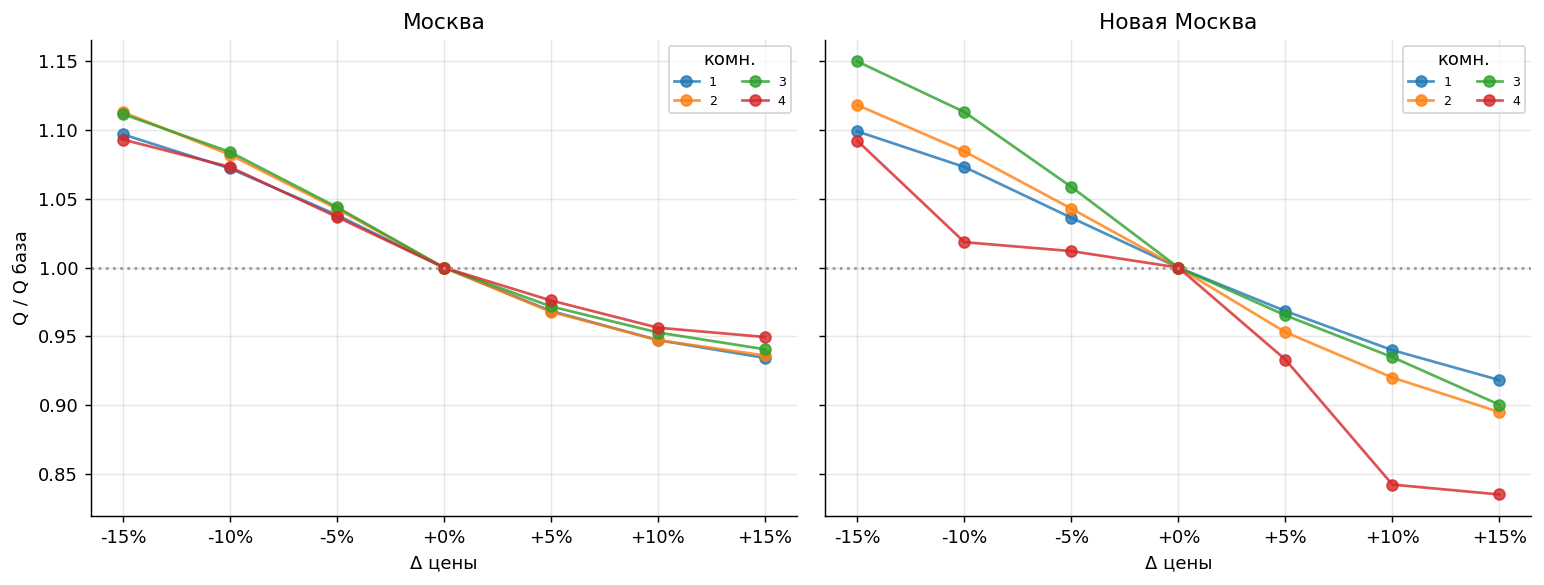

In [6]:
msk = cur[cur["region"].isin(["Москва", "Новая Москва"])].copy()
seg_room, tbl_room = segment_curves(msk, ["region", "room_count"])
display(tbl_room.sort_values(["region","room_count"])[["region","room_count",0.0,"elast_±5%","swing_%"]]
        .round({0.0:0, "elast_±5%":3, "swing_%":1}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, reg in zip(axes, ["Москва", "Новая Москва"]):
    sub = seg_room[seg_room["region"] == reg]
    for rc, grp in sub.groupby("room_count", observed=True):
        grp = grp.sort_values("pct"); base = grp.loc[grp["pct"]==0.0,"q"].iloc[0]
        ax.plot([f"{p:+.0%}" for p in grp["pct"]], grp["q"]/base, "o-", alpha=0.8, label=str(rc))
    ax.axhline(1.0, color="0.6", ls=":"); ax.set_title(reg); ax.set_xlabel("Δ цены")
    ax.legend(title="комн.", fontsize=7, ncol=2)
axes[0].set_ylabel("Q / Q база")
plt.tight_layout(); fig.savefig(FIG_DIR / "fig03_demand_room_moscow.png", bbox_inches="tight"); plt.show()

## 6. Топ-проекты (ЖК) — главный разрез дашборда

ЖК с n≥150: 226 | на графике топ-9


,project_name,n_lots,0.0,elast_±5%,swing_%
8,Равновесие,1117,44.0,-2.027,49.2
7,Пушкиноград,1190,295.0,-1.464,23.3
6,Новые Ватутинки Заречный,1061,58.0,-1.308,30.7
3,Бунинские кварталы,1612,14.0,-1.100,19.4
4,Ильинские луга,1201,3322.0,-1.062,19.9
5,Новая Ивантеевка,1052,580.0,-0.907,15.3
2,Белый град,1891,1538.0,-0.639,10.6
0,City Bay,1632,190.0,-0.595,11.2
1,Белая Дача Парк,1207,2108.0,-0.284,8.3


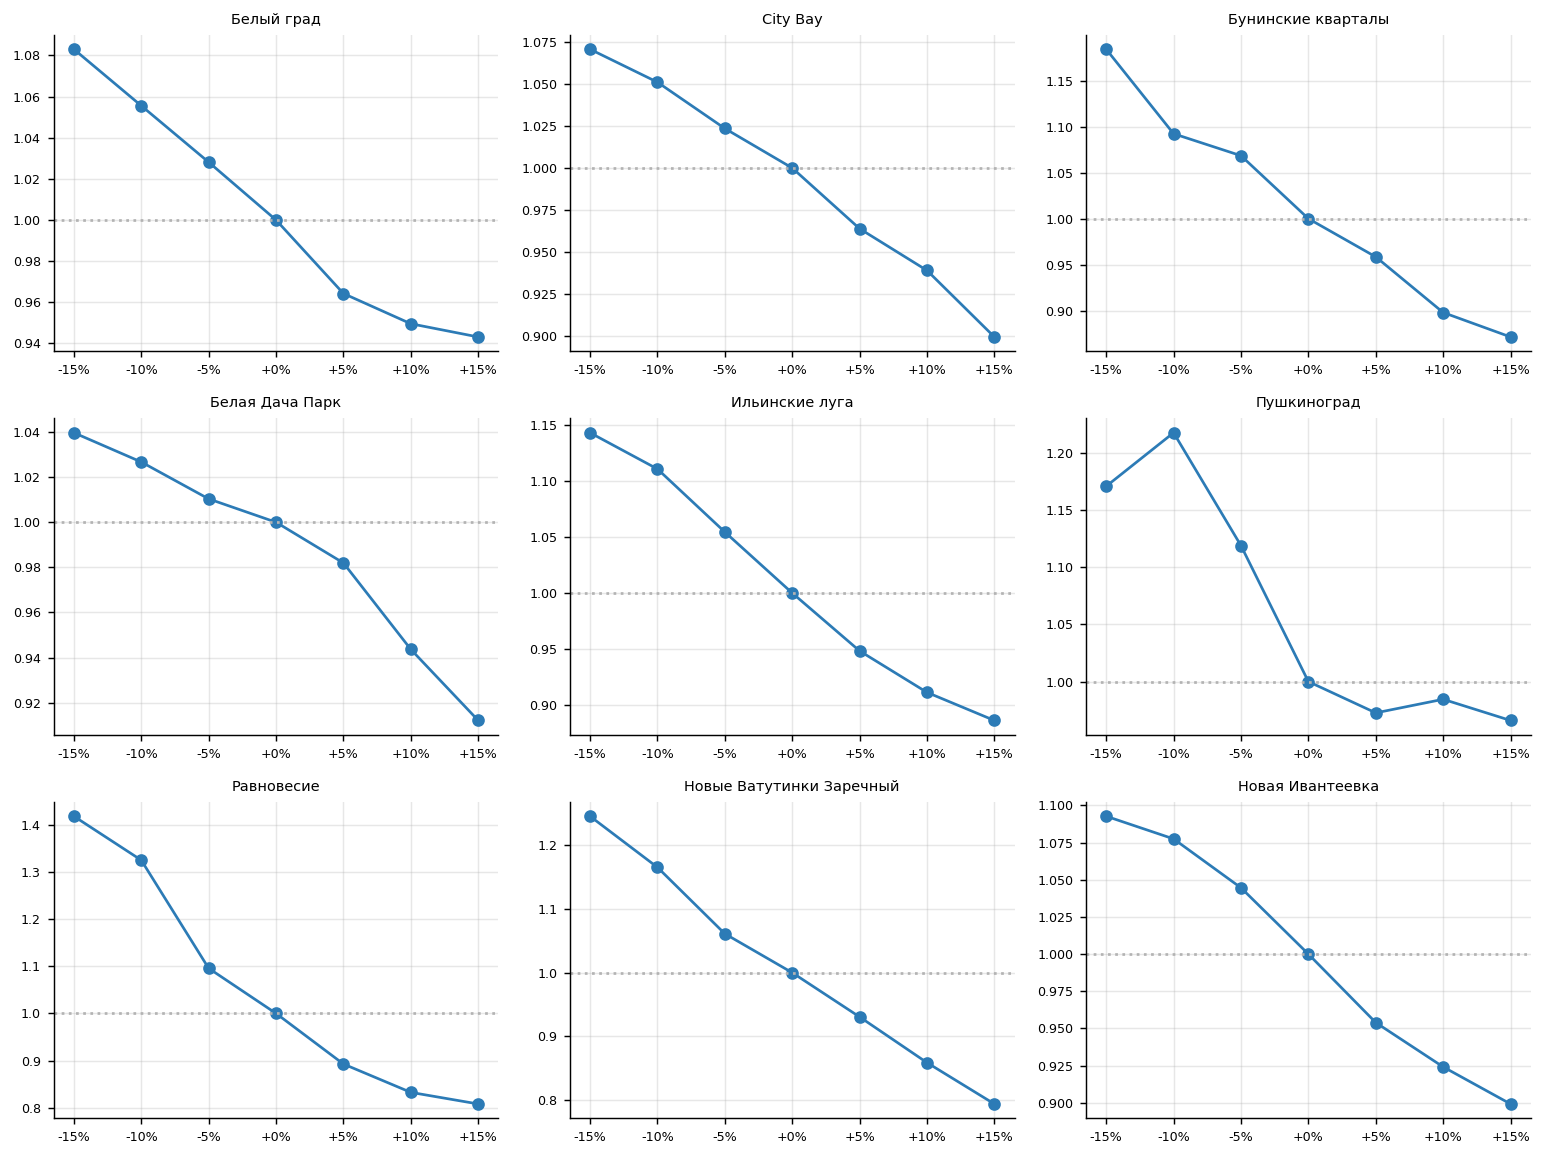

In [7]:
pc = cur["project_name"].value_counts()
top = pc[pc >= MIN_PROJ_N].head(9).index.tolist()
print(f"ЖК с n≥{MIN_PROJ_N}: {(pc>=MIN_PROJ_N).sum()} | на графике топ-{len(top)}")
seg_pr, tbl_pr = segment_curves(cur[cur["project_name"].isin(top)], ["project_name"], min_n=0)
tbl_pr = tbl_pr.merge(pc.rename("n_lots"), left_on="project_name", right_index=True).sort_values("elast_±5%")
display(tbl_pr[["project_name","n_lots",0.0,"elast_±5%","swing_%"]].round({0.0:0,"elast_±5%":3,"swing_%":1}))

fig, axes = plt.subplots(3, 3, figsize=(12, 9)); axes = axes.ravel()
for ax, pn in zip(axes, top):
    grp = seg_pr[seg_pr["project_name"] == pn].sort_values("pct")
    base = grp.loc[grp["pct"]==0.0,"q"].iloc[0]
    ax.plot([f"{p:+.0%}" for p in grp["pct"]], grp["q"]/base, "o-", color=C1)
    ax.axhline(1.0, color="0.7", ls=":"); ax.set_title(str(pn)[:26], fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes[len(top):]: ax.axis("off")
plt.tight_layout(); fig.savefig(FIG_DIR / "fig04_demand_top_projects.png", bbox_inches="tight"); plt.show()

## 7. Сохранение

In [8]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
market.to_csv(PROCESSED_DIR / "scenarios_market.csv", index=False)
tbl_rc.to_csv(PROCESSED_DIR / "scenarios_region_class.csv", index=False)
tbl_room.to_csv(PROCESSED_DIR / "scenarios_room_moscow_nm.csv", index=False)
tbl_pr.to_csv(PROCESSED_DIR / "scenarios_top_projects.csv", index=False)
print("Сохранено: scenarios_market / region_class / room_moscow_nm / top_projects .csv")
print(f"(опорный срез {REF.date()}, {len(cur):,} лотов)")

Сохранено: scenarios_market / region_class / room_moscow_nm / top_projects .csv
(опорный срез 2025-04-02, 105,400 лотов)
